<a href="https://colab.research.google.com/github/falexanderforero/Deep-Learning---Fundamentos/blob/main/week14/Semana_14_%E2%80%93_Actividad_14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Universidad de Cundinamarca
# Deep Learning Conceptos
# Freddy Alexander Forero Rojas

Importaciones y Configuración del Dispositivo

In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Configuración de hiperparámetros básicos
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Trabajando en el dispositivo: {device}")

LR = 0.0002
BATCH_SIZE = 128
EPOCHS = 10  # Pocas épocas para cumplir con las limitaciones de tiempo de la entrega
LATENT_DIM = 100  # Tamaño del vector de ruido z
IMG_SIZE = 28 * 28  # 784 px (MNIST aplanado)

Trabajando en el dispositivo: cpu


Carga de Datos (MNIST)

In [25]:
# Transformaciones: Normalizamos a [-1, 1] porque el generador usará Tanh
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

Arquitectura del Generador y Discriminador (MLP simple)

In [26]:
class Generator(nn.Module):
    def __init__(self, latent_dim, img_size):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, img_size),
            nn.Tanh()  # Escala la salida a [-1, 1] para coincidir con la normalización
        )

    def forward(self, z):
        return self.model(z)

class Discriminator(nn.Module):
    def __init__(self, img_size):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(img_size, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()  # Salida de probabilidad entre 0 y 1
        )

    def forward(self, img):
        return self.model(img)

# Instanciación y envío a GPU/CPU
netG = Generator(LATENT_DIM, IMG_SIZE).to(device)
netD = Discriminator(IMG_SIZE).to(device)

# Pérdida y optimizadores (Adam es clave en GANs)
criterion = nn.BCELoss()
optimizerG = optim.Adam(netG.parameters(), lr=LR, betas=(0.5, 0.999))
optimizerD = optim.Adam(netD.parameters(), lr=LR, betas=(0.5, 0.999))

Proceso de Entrenamiento Adversaria

In [27]:
print("Iniciando el entrenamiento...")

for epoch in range(EPOCHS):
    for i, (real_imgs, _) in enumerate(train_loader):

        # 1. Preparar datos
        real_imgs = real_imgs.view(-1, IMG_SIZE).to(device)
        batch_curr_size = real_imgs.size(0)

        # Etiquetas reales (1) y falsas (0)
        real_labels = torch.ones(batch_curr_size, 1).to(device)
        fake_labels = torch.zeros(batch_curr_size, 1).to(device)

        # ----------------------------------------------------
        # ENTRERAR DISCRIMINADOR: Maximizar log(D(x)) + log(1 - D(G(z)))
        # ----------------------------------------------------
        optimizerD.zero_grad()

        # Pasar imágenes reales por D
        outputs_real = netD(real_imgs)
        lossD_real = criterion(outputs_real, real_labels)

        # Generar imágenes falsas y pasarlas por D
        z = torch.randn(batch_curr_size, LATENT_DIM).to(device)
        fake_imgs = netG(z)
        outputs_fake = netD(fake_imgs.detach()) # .detach() para no calcular gradientes en G
        lossD_fake = criterion(outputs_fake, fake_labels)

        # Pérdida total de D y retropropagación
        lossD = lossD_real + lossD_fake
        lossD.backward()
        optimizerD.step()

        # ----------------------------------------------------
        # ENTRENAR GENERADOR: Maximizar log(D(G(z)))
        # ----------------------------------------------------
        optimizerG.zero_grad()

        # Queremos que D clasifique las falsas como reales (1)
        outputs_fake_for_G = netD(fake_imgs)
        lossG = criterion(outputs_fake_for_G, real_labels)

        lossG.backward()
        optimizerG.step()

    # Imprimir progreso por época
    print(f"Época [{epoch+1}/{EPOCHS}] | Pérdida D: {lossD.item():.4f} | Pérdida G: {lossG.item():.4f}")

Iniciando el entrenamiento...
Época [1/10] | Pérdida D: 0.9420 | Pérdida G: 1.6020
Época [2/10] | Pérdida D: 0.9714 | Pérdida G: 1.2339
Época [3/10] | Pérdida D: 0.8571 | Pérdida G: 1.4083
Época [4/10] | Pérdida D: 0.6930 | Pérdida G: 1.7064
Época [5/10] | Pérdida D: 0.6745 | Pérdida G: 2.9794
Época [6/10] | Pérdida D: 0.9342 | Pérdida G: 1.5210
Época [7/10] | Pérdida D: 1.0411 | Pérdida G: 1.1606
Época [8/10] | Pérdida D: 1.1164 | Pérdida G: 1.6260
Época [9/10] | Pérdida D: 0.9609 | Pérdida G: 1.6039
Época [10/10] | Pérdida D: 0.9791 | Pérdida G: 1.4597


Visualización de Resultados

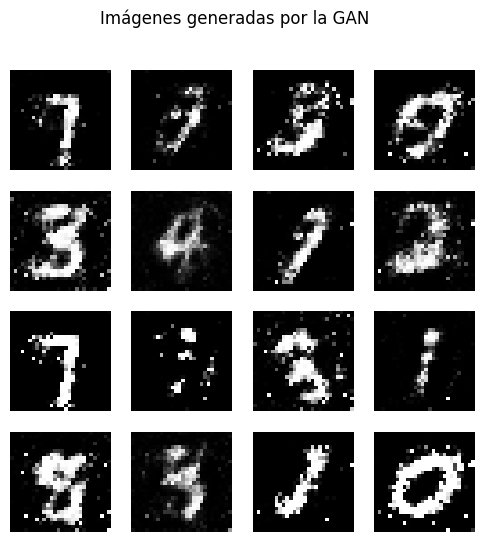

In [28]:
# Generar imágenes de prueba al final del entrenamiento
with torch.no_grad():
    z_test = torch.randn(16, LATENT_DIM).to(device)
    generated_imgs = netG(z_test).cpu().view(-1, 28, 28)

# Graficar un grid de 4x4
fig, axes = plt.subplots(4, 4, figsize=(6, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated_imgs[i], cmap='gray')
    ax.axis('off')
plt.suptitle("Imágenes generadas por la GAN")
plt.show()

1. Explicación breve sobre qué es una GAN y cómo interactúan el generador y el discriminador.
  - Respuesta: Una GAN consta de dos modelos que se entrenan simultáneamente en un juego adversarial:
    - El Generador ($G$): Toma un vector de ruido aleatorio $z$ (habitualmente de una distribución normal) y lo transforma en una imagen falsa $G(z)$. Su objetivo es "engañar" al Discriminador haciendo que sus imágenes parezcan reales.
    - El Discriminador ($D$): Es un clasificador binario. Toma una imagen (ya sea real del dataset, o falsa del Generador) y calcula la probabilidad de que sea real ($1$) o falsa ($0$).

2. Carga o generación de un dataset adecuado para la práctica, como MNIST, Fashion MNIST u otro conjunto de imágenes de baja complejidad.
- Respuesta: Se carga el Dataset MNIST.

3. Implementación del modelo generador.
- Respuesta: Se implementa.

4. Implementación del modelo discriminador.
- Respuesta: Se implementa.

5. Definición del proceso de entrenamiento adversarial.
- Respuesta:
  - Preparar datos
  - Etiquetas reales (1) y falsas (0)
  - ENTRERAR DISCRIMINADOR: Maximizar log(D(x)) + log(1 - D(G(z))).
  - Pasar imágenes reales por D
  - Generar imágenes falsas y pasarlas por D
  - Pérdida total de D y retropropagación
  - ENTRENAR GENERADOR: Maximizar log(D(G(z)))
  - Queremos que D clasifique las falsas como reales (1)

6. Ejecución del entrenamiento de la GAN, aunque sea con pocas épocas por limitaciones de recursos.
- Respuesta: Se ejecuta con 10 epocas.

7. Visualización de algunas imágenes generadas o resultados parciales del modelo.
- Respuesta: Se Visualiza las imágenes se ven como manchas borrosas o siluetas ruidosas de números.

8. Análisis breve de los resultados obtenidos, indicando dificultades, posibles mejoras y aprendizajes técnicos.
- Respuesta:

  -Inestabilidad Dinámica: Al revisar el historial de métricas, se nota que las pérdidas de $D$ y $G$ no bajan a cero de forma lineal como en una red de clasificación tradicional. Oscilan. Esto demuestra el equilibrio de Nash; si el Discriminador se vuelve demasiado perfecto muy rápido (pérdida cercana a 0), el Generador se queda sin gradientes útiles para aprender y se estanca.
  
  - Limitaciones de la Arquitectura (MLP): Se usan capas lineales simples (nn.Linear). Las capas densas no capturan bien la correlación espacial de los píxeles.Dificultades Técnicas comunes en GANs:Vanishing Gradient: Si $D$ rechaza las imágenes de $G$ con demasiada facilidad, $G$ no aprende.
  
  - Mode Collapse (Colapso de Modo): El generador descubre un único dígito (por ejemplo, un "1" borroso) que engaña medianamente bien a $D$ y empieza a generar siempre lo mismo, ignorando el resto de los números del 0 al 9.
  
  ### Posibles Mejoras
  - Cambiar a una DCGAN (Deep Convolutional GAN): Reemplazar las capas lineales por capas de Convolución Transpuesta (nn.ConvTranspose2d) en el generador y Convoluciones tradicionales en el discriminador. Esto mejora radicalmente la calidad visual de las imágenes.
  - Uso de Normalización por Lotes (Batch Normalización): Ayuda a estabilizar el entrenamiento dinámico en redes más profundas.
  - Etiquetas Suaves (Label Smoothing): En lugar de entrenar a $D$ con objetivos estrictos de 1.0 y 0.0, usar por ejemplo 0.9 para imágenes reales para reducir la confianza excesiva del discriminador al inicio del entrenamiento.

9. Enlace al notebook en Google Colab o GitHub, con permisos de visualización habilitados.
- Respuesta: Se adjunta.
